In [1]:
!pip install -r requirements.txt

In [ ]:
import os
import gdown

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from src.preprocessing import preprocess_dataframe

from src.feature_engineering import (
    build_tfidf_vectorizer,
    fit_tfidf,
    transform_tfidf,
    tokenize_texts,
    train_word2vec,
    build_sentence_vectors
)

from src.traditional_models import (
    train_logistic_regression,
    predict_logistic,
    train_lstm_model,
    predict_lstm
)

from src.llm_model import (
    load_clinicalbert,
    build_bert_embeddings
)

from src.evaluation import (
    evaluate_model,
    create_results_table,
    plot_model_comparison
)

In [ ]:
os.makedirs("data/processed", exist_ok = True)

file_id = "1m7IPUHq0hjrlQE65qzby30iR_-IV3v6L"
output_path = "data/processed/clinical_notes_dataset.csv"

url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, output_path, quiet=False)

In [3]:
df = pd.read_csv("data/processed/clinical_notes_dataset.csv")

df.head()

,subject_id,hadm_id,text,readmitted
0,6063,141296,Admission Date: [**2196-5-10**] ...,0
1,22793,107100,Admission Date: [**2105-8-24**] Dischar...,0
2,11328,163260,Admission Date: [**2173-2-10**] ...,0
3,22337,187366,Admission Date: [**2159-9-23**] ...,0
4,12794,183624,Admission Date: [**2156-5-21**] ...,0


In [4]:
df = preprocess_dataframe(df)

df.head()

,subject_id,hadm_id,text,readmitted
0,6063,141296,admission date discharge date date of birth se...,0
1,22793,107100,admission date discharge date date of birth se...,0
2,11328,163260,admission date discharge date service medicine...,0
3,22337,187366,admission date discharge date service surgery ...,0
4,12794,183624,admission date discharge date date of birth se...,0


In [5]:
# Check distribution
print(df["readmitted"].value_counts())

# Balance dataset
df_1 = df[df["readmitted"] == 1]
df_0 = df[df["readmitted"] == 0].sample(len(df_1), random_state=42)

df = pd.concat([df_1, df_0])

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check again
print(df["readmitted"].value_counts())

readmitted
0    55958
1     3694
Name: count, dtype: int64
readmitted
0    3694
1    3694
Name: count, dtype: int64


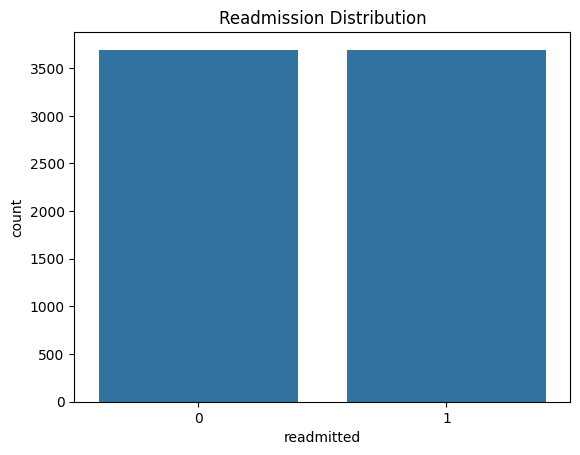

In [6]:
sns.countplot(x=df["readmitted"])

plt.title("Readmission Distribution")

plt.show()

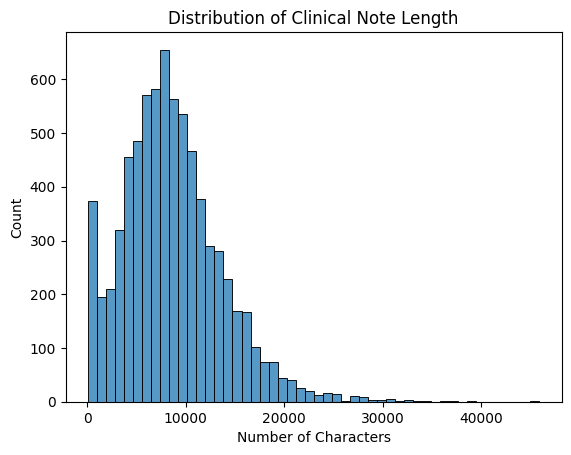

In [7]:
df["note_length"] = df["text"].apply(len)

sns.histplot(df["note_length"], bins=50)

plt.title("Distribution of Clinical Note Length")

plt.xlabel("Number of Characters")

plt.show()

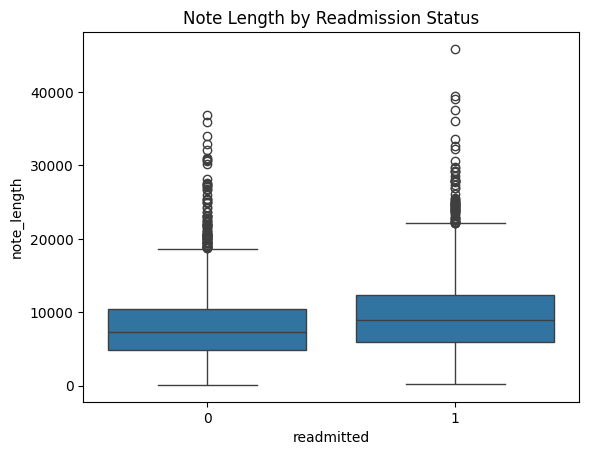

In [8]:
sns.boxplot(x="readmitted", y="note_length", data=df)

plt.title("Note Length by Readmission Status")

plt.show()

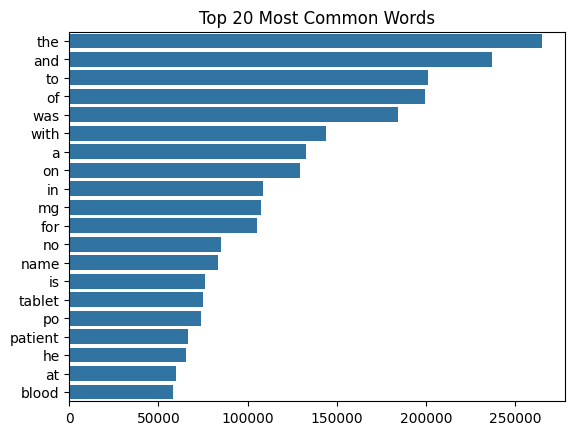

In [9]:
from collections import Counter

all_words = " ".join(df["text"]).split()

common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

sns.barplot(x=list(counts), y=list(words))

plt.title("Top 20 Most Common Words")

plt.show()

In [10]:
df_1 = df[df["readmitted"] == 1]
df_0 = df[df["readmitted"] == 0]

words_1 = Counter(" ".join(df_1["text"]).split()).most_common(10)
words_0 = Counter(" ".join(df_0["text"]).split()).most_common(10)

print("Readmitted:", words_1)
print("Not Readmitted:", words_0)

Readmitted: [('the', 138358), ('and', 125669), ('to', 108543), ('of', 106814), ('was', 96520), ('with', 77358), ('a', 71623), ('on', 70450), ('mg', 62410), ('in', 59012)]
Not Readmitted: [('the', 126680), ('and', 111662), ('of', 92981), ('to', 92962), ('was', 88004), ('with', 66381), ('a', 61090), ('on', 58785), ('in', 49497), ('for', 47975)]


**Train / Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["readmitted"],
    test_size=0.2,
    random_state=42
)

*Logistic Regression*

**Feature extraction**

In [12]:
tfidf_vectorizer = build_tfidf_vectorizer()

X_train_tfidf = fit_tfidf(tfidf_vectorizer, X_train)

X_test_tfidf = transform_tfidf(tfidf_vectorizer, X_test)

**Train model**

In [13]:
log_model = train_logistic_regression(X_train_tfidf, y_train)

log_preds = predict_logistic(log_model, X_test_tfidf)
log_probs = log_model.predict_proba(X_test_tfidf)[:, 1]

**Evaluate**

In [14]:
log_results = evaluate_model(y_test, log_preds, log_probs)

log_results

{'accuracy': 0.6711772665764547,
 'precision': 0.6648721399730821,
 'recall': 0.6757865937072504,
 'f1_score': 0.6702849389416553,
 'auc': 0.738274575731105}

*Traditional Deep Learning*

**Tokenization**

In [15]:
tokenized_train = tokenize_texts(X_train)

tokenized_test = tokenize_texts(X_test)

**Train Word2Vec**

In [16]:
w2v_model = train_word2vec(tokenized_train)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


**Convert sentences to vectors**

In [17]:
X_train_vec = build_sentence_vectors(X_train, w2v_model)

X_test_vec = build_sentence_vectors(X_test, w2v_model)

**Train LSTM**

In [18]:
lstm_model = train_lstm_model(X_train_vec, y_train)

**Predict**

In [19]:
lstm_preds, lstm_probs = predict_lstm(lstm_model, X_test_vec)

**Evaluate**

In [20]:
lstm_results = evaluate_model(y_test, lstm_preds, lstm_probs)

lstm_results

{'accuracy': 0.5480378890392422,
 'precision': 0.5981308411214953,
 'recall': 0.26265389876880985,
 'f1_score': 0.3650190114068441,
 'auc': 0.6061207895879002}

*LLM Model — ClinicalBERT*

**Load model**

In [21]:
tokenizer, bert_model = load_clinicalbert()

**BERT is slow, so start with a subset**

In [ ]:
X_train_small = X_train[:1000]
y_train_small = y_train[:1000]

X_test_small = X_test[:300]
y_test_small = y_test[:300]

**Generate embeddings**

In [23]:
X_train_bert = build_bert_embeddings(
    X_train_small,
    tokenizer,
    bert_model
)

X_test_bert = build_bert_embeddings(
    X_test_small,
    tokenizer,
    bert_model
)

100%|██████████| 300/300 [00:12<00:00, 24.39it/s]


**Train classifier**

In [24]:
from sklearn.linear_model import LogisticRegression

bert_classifier = LogisticRegression(max_iter=1000, class_weight="balanced")

bert_classifier.fit(X_train_bert, y_train_small)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

**Predict**

In [25]:
bert_preds = bert_classifier.predict(X_test_bert)
bert_probs = bert_classifier.predict_proba(X_test_bert)[:, 1]

**Evaluate**

In [26]:
bert_results = evaluate_model(y_test_small, bert_preds, bert_probs)

bert_results

{'accuracy': 0.6133333333333333,
 'precision': 0.6341463414634146,
 'recall': 0.65,
 'f1_score': 0.6419753086419753,
 'auc': 0.6241071428571429}

*Compare All Models*

**Create results dictionary**

In [30]:
results = {
    "TF-IDF + Logistic": log_results,
    "Word2Vec + LSTM": lstm_results,
    "ClinicalBERT": bert_results
}

results

{'TF-IDF + Logistic': {'accuracy': 0.6711772665764547,
  'precision': 0.6648721399730821,
  'recall': 0.6757865937072504,
  'f1_score': 0.6702849389416553,
  'auc': 0.738274575731105},
 'Word2Vec + LSTM': {'accuracy': 0.5480378890392422,
  'precision': 0.5981308411214953,
  'recall': 0.26265389876880985,
  'f1_score': 0.3650190114068441,
  'auc': 0.6061207895879002},
 'ClinicalBERT': {'accuracy': 0.6133333333333333,
  'precision': 0.6341463414634146,
  'recall': 0.65,
  'f1_score': 0.6419753086419753,
  'auc': 0.6241071428571429}}

**Build table**

In [28]:
results_df = create_results_table(results)

results_df

,Model,accuracy,precision,recall,f1_score,auc
0,TF-IDF + Logistic,0.671177,0.664872,0.675787,0.670285,0.738275
1,Word2Vec + LSTM,0.548038,0.598131,0.262654,0.365019,0.606121
2,ClinicalBERT,0.613333,0.634146,0.650000,0.641975,0.624107


**Plot Results**

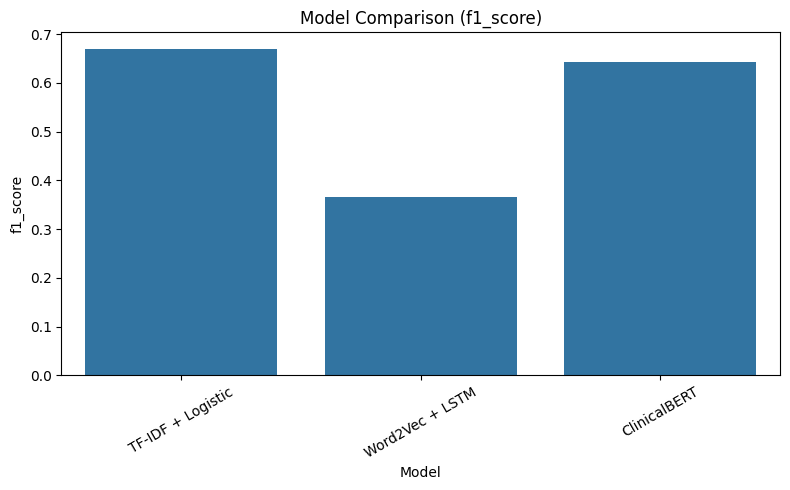

In [29]:
plot_model_comparison(results_df, metric="f1_score")